# Fase 2. Cribado de variables por información mutua

**Tesis** · Desigualdades socioeconómicas, étnicas y territoriales en el bajo peso al nacer
en Colombia, 1998-2024
**Corresponde a** · Capítulo 4, Sección 4.4.2 · Capítulo 3, Sección 3.4.2

| | |
|---|---|
| **Entra** | `intermedios/muestra_analitica.parquet` |
| **Sale** | `salidas/tablas/cribado_mi.csv`, `seleccion_adelante.csv`, `matriz_interaccion.csv`, dos figuras |
| **Tiempo** | 3 a 6 minutos |

---

## Las tres formas de la misma medida

| | Fórmula | Qué responde |
|---|---|---|
| **Marginal** | $I(X;Y)$ | ¿X sola informa sobre el desenlace? |
| **Condicional** | $I(X;Y \mid Z)$ | ¿X añade algo **dado que ya tengo Z**? |
| **Interacción** | $I(X,Z;Y) - I(X;Y) - I(Z;Y)$ | positiva = **sinergia**, negativa = redundancia |

Las tres son información mutua. Misma teoría, mismas unidades, mismo Shannon. Lo único que
cambia es sobre qué se condiciona.

## Por qué no basta la marginal

Una variable puede tener información mutua marginal prácticamente nula y ser decisiva en
combinación con otra. El **bloque 3** de este notebook lo demuestra con una simulación que
puedes correr y mostrar.

Si el cribado usara solo la marginal, esa variable quedaría eliminada, y con ella la
interacción que el componente predictivo busca. Por eso la retención admite **dos vías**:
superar el nulo en marginal **o** en condicional.

## Referencias del método

- **Battiti (1994)** — origen del cribado por información mutua
- **Peng, Long y Ding (2005)** — máxima relevancia, mínima redundancia
- **Vergara y Estévez (2013)** — revisión de los métodos basados en información mutua

## 0. Entorno

**Qué hacemos.** Importamos `src/cribado.py`, que contiene las tres medidas y el
procedimiento de selección.

**Por qué un módulo aparte.** Las funciones de teoría de la información se usan también en
la Fase 7 y en el análisis de sensibilidad. Si viven en un notebook, los demás las copian y
las copias se desincronizan.

In [1]:
# ---------------------------------------------------------------------------
# Entorno
# ---------------------------------------------------------------------------

import sys
from pathlib import Path

# VS Code ejecuta los notebooks desde la carpeta abierta como proyecto, no
# desde notebooks/. Se busca la raiz hacia arriba en vez de usar una ruta
# relativa fija, que fallaria en uno de los dos casos.
def _encontrar_raiz(inicio: Path) -> Path:
    for candidata in [inicio, *inicio.parents]:
        if (candidata / "src" / "config.py").exists():
            return candidata
    raise FileNotFoundError(f"No encuentro src/config.py subiendo desde {inicio}")

RAIZ = _encontrar_raiz(Path.cwd())
sys.path.insert(0, str(RAIZ / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import SEMILLA, CONTROL, DIR_INTERMEDIOS
from datos import leer_intermedio, guardar_intermedio
from util import cronometro, guardar_tabla, versiones
from graficos import estilo, guardar_figura

# Modulo de teoria de la informacion del proyecto.
from cribado import (im, entropia, im_condicional, informacion_interaccion,
                     nulo_permutacion, seleccion_adelante, matriz_interaccion,
                     codificar)

estilo()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

print(f"raiz: {RAIZ}")
print(f"semilla: {SEMILLA}")

raiz: c:\Users\ASUS\Desktop\TESIS\CODIGO_VSC
semilla: 2024


**Cómo se lee esta salida.** Solo confirma las rutas. Si sale
`ModuleNotFoundError: cribado`, falta `src/cribado.py`.

## 1. Partición: el cribado se calcula solo sobre entrenamiento

**Qué hacemos.** Creamos la partición entrenamiento/prueba **antes** de calcular nada, y a
partir de aquí trabajamos solo con entrenamiento.

**Por qué es lo primero y no un detalle.** Calcular la información mutua sobre toda la base
y particionar después es **fuga de información**: la selección de predictores habría visto
los desenlaces del conjunto de prueba, y el desempeño que reporte la Fase 7 estaría inflado.
No daría ningún error; simplemente los resultados serían optimistas y no reproducibles fuera
de la muestra.

**Decisión: partición estratificada por año.** Con prevalencia del 8,8 % y una tendencia
temporal, una partición aleatoria simple podría desbalancear los años. Se estratifica por
año y por desenlace.

**Sobre la muestra de trabajo.** El cálculo de la información mutua condicional recorre
estratos, y sobre 17 millones de registros cada permutación cuesta. Se usa una submuestra
estratificada con semilla fija; el efecto sobre las estimaciones es despreciable frente al
tamaño, y se declara.

In [2]:
# ---------------------------------------------------------------------------
# Carga y particion
# ---------------------------------------------------------------------------

# Se declaran ANTES de leer, para cargar solo las columnas necesarias.
SOCIALES = ["NIV_EDUM", "NIV_EDUP", "SEG_SOCIAL", "EST_CIVM", "AREA_RES", "IDPERTET"]
OBSTETRICAS = ["SEXO", "MUL_PARTO", "TIPO_PARTO", "SIT_PARTO",
               "EDAD_MADRE", "NUMCONSUL", "N_EMB", "N_HIJOSV", "T_GES"]

# POR QUE LEER POR COLUMNAS: la muestra son 17 millones de filas por 53
# columnas. El analisis usa quince. Parquet es columnar, asi que leer solo lo
# necesario no es una optimizacion menor: es la diferencia entre que el
# notebook quepa en memoria o no.
COLUMNAS = ["ANIO", "BPN"] + SOCIALES + OBSTETRICAS

with cronometro("lectura de la muestra analitica"):
    muestra = leer_intermedio("muestra_analitica", columnas=COLUMNAS)

print(f"columnas leidas: {muestra.shape[1]} de 53")
print(f"memoria: {muestra.memory_usage(deep=True).sum()/1024**3:.2f} GB")

print(f"muestra analitica: {len(muestra):,} registros")
esperado = CONTROL["muestra_analitica"]
if len(muestra) != esperado:
    print(f"  AVISO: el manuscrito declara {esperado:,}. Difiere en "
          f"{len(muestra) - esperado:+,}.")
    print("  Si la diferencia es grande, vuelve a correr 01_eda.ipynb: las")
    print("  exclusiones de datos.py cambiaron.")

# --- Particion entrenamiento / prueba --------------------------------------
#
# POR QUE ASIGNACION ALEATORIA SIMPLE Y NO ESTRATIFICADA
#     Estratificar exige construir la clave del estrato y ordenar dentro de
#     cada uno. Sobre diecisiete millones de filas eso son varios arreglos
#     auxiliares del mismo tamano, y agota la memoria de un portatil aunque la
#     tabla ocupe menos de medio giga.
#
#     Con esta cantidad de datos la estratificacion no hace falta: la ley de
#     los grandes numeros equilibra sola. Lo que SI hace falta es comprobarlo,
#     y eso es lo que hace el bloque de verificacion. Declarar y verificar es
#     mejor que imponer y no mirar.
rng = np.random.default_rng(SEMILLA)
PROP_PRUEBA = 0.30
# float32 en vez de float64: la mitad de memoria y precision de sobra para
# comparar contra un umbral.
u = rng.random(len(muestra), dtype=np.float32)
es_prueba = u < PROP_PRUEBA
del u

# La particion se guarda como BOOLEANO, no como texto.
#
# np.where(es_prueba, "prueba", "entrenamiento") crearia un arreglo de
# diecisiete millones de cadenas de trece caracteres: unos 900 MB solo para
# distinguir dos categorias. Un booleano ocupa un byte por fila, es decir 17 MB.
# Es la diferencia entre que el notebook termine o lo mate el sistema.
guardar_intermedio(pd.DataFrame({"es_prueba": es_prueba}), "particion")

n_tr = int((~es_prueba).sum())
print(f"\nentrenamiento: {n_tr:,}  ({n_tr/len(muestra)*100:.1f} %)")
print(f"prueba       : {int(es_prueba.sum()):,}")

# --- Verificacion del equilibrio -------------------------------------------
# Se comprueba sobre un DataFrame ligero de tres columnas, no copiando la
# tabla completa.
chk = pd.DataFrame({
    "ANIO": muestra["ANIO"].to_numpy(dtype=np.int16),
    "BPN": muestra["BPN"].to_numpy(dtype=np.int8),
    "prueba": es_prueba,
})
prev_tr = chk.loc[~chk["prueba"]].groupby("ANIO")["BPN"].mean()
prev_te = chk.loc[chk["prueba"]].groupby("ANIO")["BPN"].mean()
dif_pp = ((prev_te - prev_tr) * 100).abs()

print(f"\nprevalencia entrenamiento: {chk.loc[~chk['prueba'],'BPN'].mean()*100:.3f} %")
print(f"prevalencia prueba       : {chk.loc[chk['prueba'],'BPN'].mean()*100:.3f} %")
print(f"\ndesviacion por anio: maxima {dif_pp.max():.3f} pp, "
      f"mediana {dif_pp.median():.3f} pp")
if dif_pp.max() > 0.5:
    print("  AVISO: mas de medio punto en algun anio. Revisa la particion.")
else:
    print("  El equilibrio por anio es adecuado; no hace falta estratificar.")
del chk, prev_tr, prev_te

# --- Submuestra de trabajo para el cribado ---------------------------------
#
# El calculo de la informacion mutua condicional recorre estratos, y cada
# permutacion del nulo repite ese recorrido. Sobre doce millones de filas el
# procedimiento no termina en un tiempo razonable. Se usa una submuestra con
# semilla fija; el efecto sobre las estimaciones es despreciable frente al
# tamano, y queda declarado en la metodologia.
N_TRABAJO = 400_000
idx_tr = np.flatnonzero(~es_prueba)
if idx_tr.size > N_TRABAJO:
    elegidos = rng.choice(idx_tr, size=N_TRABAJO, replace=False)
else:
    elegidos = idx_tr

trabajo = muestra.iloc[elegidos].copy()
print(f"\nsubmuestra de trabajo: {len(trabajo):,} "
      f"(prevalencia {trabajo['BPN'].mean()*100:.2f} %)")

# Liberar la tabla grande: a partir de aqui todo trabaja sobre la submuestra.
del muestra, es_prueba, idx_tr, elegidos

[inicio] lectura de la muestra analitica
[fin]    lectura de la muestra analitica  ->  1.8 s
columnas leidas: 17 de 53
memoria: 0.40 GB
muestra analitica: 17,376,860 registros
guardado: particion.parquet  (17,376,860 filas)

entrenamiento: 12,164,753  (70.0 %)
prueba       : 5,212,107

prevalencia entrenamiento: 8.777 %
prevalencia prueba       : 8.788 %

desviacion por anio: maxima 0.217 pp, mediana 0.053 pp
  El equilibrio por anio es adecuado; no hace falta estratificar.

submuestra de trabajo: 400,000 (prevalencia 8.81 %)


**Cómo se lee esta salida.**

- Las dos prevalencias, entrenamiento y prueba, deben coincidir hasta la primera decimal.
  Si difieren, la estratificación falló.
- **Si sale el aviso de que la muestra no coincide con el manuscrito**, vuelve a correr
  `01_eda.ipynb`. Las exclusiones se corrigieron y el intermedio puede ser de la versión
  anterior.

**Qué va al manuscrito.** El tamaño de la partición y el hecho de que el cribado se ajusta
solo sobre entrenamiento van a la Sección 4.4.2.

## 2. Entropía del desenlace: cuánto hay que explicar

**Qué hacemos.** Calculamos $H(Y)$, la entropía de Shannon del indicador de bajo peso.

**Por qué antes de nada.** $H(Y)$ es el **techo**: ninguna variable puede aportar más
información que la incertidumbre que existe. Con prevalencia cercana al 8,8 %, el desenlace
es muy poco incierto de partida, y eso acota lo que cualquier predictor puede dar.

Sin este número, una información mutua de 0,005 bits no se sabe si es mucho o poco.

In [3]:
# ---------------------------------------------------------------------------
# Entropia del desenlace
# ---------------------------------------------------------------------------

h_y = entropia(trabajo["BPN"])
p = trabajo["BPN"].mean()

print(f"prevalencia         : {p*100:.2f} %")
print(f"H(Y)                : {h_y:.4f} bits")
print(f"maximo posible      : 1.0000 bits  (si la prevalencia fuera del 50 %)")
print(f"\nEl desenlace usa el {h_y*100:.1f} % de la incertidumbre maxima de una")
print("variable binaria. Ese es el techo de lo que cualquier variable puede aportar.")

prevalencia         : 8.81 %
H(Y)                : 0.4303 bits
maximo posible      : 1.0000 bits  (si la prevalencia fuera del 50 %)

El desenlace usa el 43.0 % de la incertidumbre maxima de una
variable binaria. Ese es el techo de lo que cualquier variable puede aportar.


**Cómo se lee esta salida.** Con prevalencia del 8,8 %, $H(Y) \approx 0{,}43$
bits. Una variable con información mutua de 0,005 bits explica alrededor del **1 %** de la
incertidumbre total. Parece poco, y lo es en términos absolutos: es lo normal en
epidemiología social, donde ningún determinante individual determina el desenlace.

**Frase para el manuscrito.** La comparación relevante entre variables es **relativa**, no
contra un umbral absoluto de bits.

## 3. Demostración: por qué la marginal no basta

**Qué hacemos.** Simulamos dos variables cuya relación con el desenlace es **puramente de
interacción**: el riesgo sube solo cuando ambas coinciden. Después las medimos con las tres
formas de la información mutua.

**Por qué está esto en el notebook y no en un anexo.** Es la justificación de todo el
procedimiento que viene después. Si alguien pregunta por qué no se cribó con la marginal,
esta celda es la respuesta, y se puede ejecutar delante de quien pregunte.

**Qué esperamos ver.** Que la variable B tenga información mutua marginal por debajo de su
propio nulo —es decir, indistinguible del azar— y sin embargo información mutua condicional
tres órdenes de magnitud mayor.

In [4]:
# ---------------------------------------------------------------------------
# DEMOSTRACION: la informacion mutua marginal es ciega a las interacciones
# ---------------------------------------------------------------------------

rng = np.random.default_rng(SEMILLA)
n_sim = 200_000

# Dos determinantes binarios INDEPENDIENTES entre si.
A = pd.Series(rng.integers(0, 2, n_sim))   # p.ej. area rural
B = pd.Series(rng.integers(0, 2, n_sim))   # p.ej. regimen subsidiado
C_ = pd.Series(rng.integers(0, 2, n_sim))  # una con efecto principal, de control

# El riesgo depende de que A y B COINCIDAN, no de cada una por separado.
# Es el caso limite: efecto principal cero, interaccion fuerte.
logit = -2.4 + 0.9 * (A == B) + 0.5 * C_
Y_sim = pd.Series((rng.random(n_sim) < 1 / (1 + np.exp(-logit))).astype(int))

print(f"prevalencia simulada: {Y_sim.mean()*100:.2f} %\n")

print("PREVALENCIA REAL POR COMBINACION")
d = pd.DataFrame({"A": A, "B": B, "Y": Y_sim})
tabla = d.groupby(["A", "B"])["Y"].mean().mul(100).round(2)
print(tabla.to_string())
print("  -> 22 % contra 10 %: la interaccion es enorme\n")

print("LAS TRES MEDIDAS SOBRE LA VARIABLE B")
im_marg = im(B, Y_sim)
im_cond = im_condicional(B, Y_sim, A, min_estrato=1000)
ii = informacion_interaccion(A, B, Y_sim)

# Nulo por permutacion de la marginal, el mismo criterio del cribado real.
nulo = nulo_permutacion(B, Y_sim, n_perm=300, semilla=SEMILLA)

print(f"  MARGINAL      I(B;Y)     = {im_marg:.6f} bits")
print(f"     nulo p95              = {nulo['p95']:.6f} bits")
print(f"     -> ¿supera el nulo?   = {im_marg > nulo['p95']}   <-- SERIA ELIMINADA")
print(f"  CONDICIONAL   I(B;Y | A) = {im_cond:.6f} bits   "
      f"({im_cond/max(im_marg,1e-12):,.0f} veces mas)")
print(f"  INTERACCION   A-B        = {ii:+.6f} bits   -> SINERGIA")

print("\nCOMPARACION con C, que si tiene efecto principal:")
print(f"  I(C;Y)     = {im(C_, Y_sim):.6f}")
print(f"  I(C;Y | A) = {im_condicional(C_, Y_sim, A, min_estrato=1000):.6f}   (parecido)")
print(f"  interaccion A-C = {informacion_interaccion(A, C_, Y_sim):+.6f}   (≈ 0)")

prevalencia simulada: 16.70 %

PREVALENCIA REAL POR COMBINACION
A  B
0  0    22.70
   1    10.73
1  0    10.83
   1    22.63
  -> 22 % contra 10 %: la interaccion es enorme

LAS TRES MEDIDAS SOBRE LA VARIABLE B
  MARGINAL      I(B;Y)     = 0.000001 bits
     nulo p95              = 0.000015 bits
     -> ¿supera el nulo?   = False   <-- SERIA ELIMINADA
  CONDICIONAL   I(B;Y | A) = 0.018642 bits   (17,538 veces mas)
  INTERACCION   A-B        = +0.018641 bits   -> SINERGIA

COMPARACION con C, que si tiene efecto principal:
  I(C;Y)     = 0.005768
  I(C;Y | A) = 0.005772   (parecido)
  interaccion A-C = +0.000004   (≈ 0)


**Cómo se lee esta salida. Este es el bloque que hay que saber explicar.**

- **La tabla de prevalencias** muestra una interacción brutal: alrededor del 22 % cuando A y
  B coinciden, del 10 % cuando no. Nadie discutiría que B importa.
- **Y sin embargo `I(B;Y)` no supera su propio nulo por permutación.** Un cribado marginal la
  eliminaría, y con ella la interacción.
- **`I(B;Y|A)` es del orden de mil veces mayor.** Condicionando sobre A, B aparece.
- **La información de interacción es positiva**, y eso es el diagnóstico: hay sinergia.
- **El contraste con C** cierra el argumento: C tiene efecto principal, su condicional se
  parece a su marginal, y su interacción con A es prácticamente cero. La medida distingue
  los dos casos.

**Frase para la sustentación.**

> *La información mutua marginal responde si una variable informa por sí sola. Si la
> relación es de interacción, la respuesta es no, aunque la variable sea decisiva. Por eso
> el cribado de este trabajo evalúa también la información mutua condicional, y una
> variable se retiene si supera su nulo por cualquiera de las dos vías.*

## 4. Información mutua marginal de los determinantes reales

**Qué hacemos.** Calculamos $I(X;Y)$ de cada determinante candidato, con su nulo por
permutación.

**Por qué el nulo es por variable y no un umbral común.** La información mutua estimada
sobre una muestra finita es sistemáticamente positiva **incluso bajo independencia**, y el
sesgo crece con el número de celdas de la tabla conjunta. Un umbral absoluto sería exigente
para una variable dicotómica y laxo para una de mil niveles. El nulo por permutación
preserva la cardinalidad y el tamaño de muestra, que es lo que gobierna el sesgo, y destruye
solo la asociación.

**Qué candidatas entran.** Los determinantes sociales y las variables obstétricas. Quedan
fuera los metadatos y todo lo que se conoce durante o después del parto, por fuga de
información.

In [5]:
# ---------------------------------------------------------------------------
# Informacion mutua marginal, con nulo por permutacion
# ---------------------------------------------------------------------------

# SOCIALES y OBSTETRICAS se declararon en el bloque 1, antes de leer.
CANDIDATAS = [v for v in SOCIALES + OBSTETRICAS if v in trabajo.columns]
ausentes = [v for v in SOCIALES + OBSTETRICAS if v not in trabajo.columns]
if ausentes:
    print(f"AVISO: no estan en la matriz y se omiten: {ausentes}\n")

filas = []
with cronometro("informacion mutua marginal + nulos"):
    for v in CANDIDATAS:
        valor = im(trabajo[v], trabajo["BPN"])
        h_x = entropia(trabajo[v])
        nulo = nulo_permutacion(trabajo[v], trabajo["BPN"],
                                n_perm=200, semilla=SEMILLA)
        filas.append({
            "variable": v,
            "bloque": "social" if v in SOCIALES else "obstetrica",
            "niveles": int(trabajo[v].nunique(dropna=True)),
            "completitud_pct": round(trabajo[v].notna().mean() * 100, 2),
            "H_X_bits": round(h_x, 4),
            "im_bits": round(valor, 6),
            # Incertidumbre simetrica: IM normalizada por las entropias, para
            # comparar variables de cardinalidad distinta.
            "incert_simetrica": round(2 * valor / (h_x + h_y), 6),
            "pct_de_H_Y": round(valor / h_y * 100, 3),
            "nulo_p95": round(nulo["p95"], 6),
            "razon_nulo": round(valor / nulo["p95"], 1) if nulo["p95"] > 0 else np.nan,
            "supera_marginal": valor > nulo["p95"],
        })

cribado = pd.DataFrame(filas).sort_values("im_bits", ascending=False)
guardar_tabla(cribado, "cribado_mi", decimales=6)
cribado

[inicio] informacion mutua marginal + nulos
[fin]    informacion mutua marginal + nulos  ->  81.0 s
tabla guardada: cribado_mi.csv y cribado_mi.tex


,variable,bloque,niveles,completitud_pct,H_X_bits,im_bits,incert_simetrica,pct_de_H_Y,nulo_p95,razon_nulo,supera_marginal
14,T_GES,obstetrica,5,100.00,0.7747,0.110425,0.183288,25.665,0.000017,6585.2,True
7,MUL_PARTO,obstetrica,4,99.30,0.1350,0.022246,0.078706,5.170,0.000014,1568.2,True
8,TIPO_PARTO,obstetrica,4,99.78,1.0580,0.007176,0.009644,1.668,0.000014,507.4,True
11,NUMCONSUL,obstetrica,44,93.85,4.2835,0.006344,0.002692,1.475,0.000110,57.5,True
10,EDAD_MADRE,obstetrica,9,99.79,2.3894,0.000767,0.000544,0.178,0.000028,27.8,True
3,EST_CIVM,social,6,97.76,2.1600,0.000608,0.000469,0.141,0.000023,26.4,True
6,SEXO,obstetrica,3,100.00,0.9999,0.000539,0.000754,0.125,0.000011,49.1,True
12,N_EMB,obstetrica,23,99.32,2.1823,0.000510,0.000390,0.118,0.000060,8.5,True
1,NIV_EDUP,social,22,88.35,3.5505,0.000500,0.000251,0.116,0.000073,6.9,True
0,NIV_EDUM,social,22,96.78,3.5637,0.000434,0.000217,0.101,0.000065,6.7,True


**Cómo se lee esta salida.**

- **`pct_de_H_Y`** es la lectura interpretable: qué fracción de la incertidumbre del
  desenlace explica cada variable. Es más informativo que los bits en bruto.
- **`razon_nulo`** dice cuántas veces supera la variable a su propio azar. Por debajo de 1
  no se distingue del ruido.
- **Mira el orden por bloque.** Si las obstétricas dominan a las sociales por uno o dos
  órdenes de magnitud, eso **no** significa que los determinantes sociales no importen:
  significa que las obstétricas son **mediadores**, están más cerca del desenlace en la
  cadena causal y por eso absorben la información.

**Y aquí está el punto que hay que tener clarísimo.** Si el cribado decidiera la
especificación de los modelos multinivel, eliminaría los determinantes sociales, que son el
objeto de la tesis, y conservaría los mediadores. Sería el mismo error de siempre en otra
forma: seleccionar por asociación con el desenlace mete mediadores y expulsa confusores.

Por eso el cribado se aplica **solo al componente predictivo**. Volvemos sobre esto en el
bloque 7.

## 5. Selección hacia adelante por información mutua condicional

**Qué hacemos.** Selección paso a paso: entra primero la de mayor información mutua
marginal; a partir de ahí cada candidata se evalúa por $I(X;Y \mid S)$, donde $S$ es lo ya
seleccionado.

**Por qué hacia adelante y no en una sola pasada.** Porque una variable puede tener marginal
nula y aporte condicional alto — es lo que demostró el bloque 3. Evaluarlas todas a la vez
sin condicionar es exactamente lo que deja fuera las interacciones.

**Cómo se implementa el condicionamiento.** Estratificando por la combinación de las
variables ya seleccionadas y promediando la información mutua dentro de cada estrato,
ponderada por su tamaño.

**Limitación que hay que declarar, y que se va a ver en la salida.** El número de estratos
crece de forma **multiplicativa**: dos variables de cinco niveles dan 25 estratos, cuatro dan
625. A partir de unas pocas variables los estratos se vacían, la estimación se degrada y el
nulo por permutación sube hasta alcanzar a la señal. El procedimiento se detiene solo.

**Eso no es un defecto de programación: es el límite de estimar $I(X;Y|S)$ de forma no
paramétrica cuando $S$ crece.** Declararlo es parte del método.

In [6]:
# ---------------------------------------------------------------------------
# Seleccion hacia adelante por informacion mutua condicional
# ---------------------------------------------------------------------------

# min_estrato: por debajo de este tamano, la IM dentro del estrato es casi todo
# sesgo y el estrato se descarta, renormalizando los pesos.
MIN_ESTRATO = 300
N_PERM = 100

with cronometro("seleccion hacia adelante"):
    seleccion = seleccion_adelante(
        trabajo, CANDIDATAS, "BPN",
        n_perm=N_PERM, semilla=SEMILLA,
        min_estrato=MIN_ESTRATO, max_vars=8,
    )

guardar_tabla(seleccion, "seleccion_adelante", decimales=6)
print()
seleccion

[inicio] seleccion hacia adelante
  paso 1: T_GES        I(X;Y)   = 0.110425   nulo p95 = 0.000021   ENTRA
  paso 2: MUL_PARTO    I(X;Y|S) = 0.008797   nulo p95 = 0.000030   ENTRA
  paso 3: NUMCONSUL    I(X;Y|S) = 0.002686   nulo p95 = 0.000517   ENTRA
  paso 4: N_HIJOSV     I(X;Y|S) = 0.002480   nulo p95 = 0.001174   ENTRA
  paso 5: NIV_EDUP     I(X;Y|S) = 0.003664   nulo p95 = 0.003931   NO supera -> se detiene
[fin]    seleccion hacia adelante  ->  45.5 s
tabla guardada: seleccion_adelante.csv y seleccion_adelante.tex



,paso,variable,tipo_im,im_bits,nulo_p95,razon_nulo,supera_nulo,n_estratos
0,1,T_GES,marginal,0.110425,0.000021,5219.74,True,1
1,2,MUL_PARTO,condicional,0.008797,0.000030,290.86,True,5
2,3,NUMCONSUL,condicional,0.002686,0.000517,5.20,True,16
3,4,N_HIJOSV,condicional,0.002480,0.001174,2.11,True,373
4,5,NIV_EDUP,condicional,0.003664,0.003931,0.93,False,2062


**Cómo se lee esta salida.**

- **`tipo_im`** cambia de `marginal` en el paso 1 a `condicional` a partir del 2. El paso 1
  no tiene sobre qué condicionar.
- **`n_estratos`** crece rápido. Cuando llega a varios miles, cada estrato tiene pocas
  observaciones y la estimación deja de ser fiable. Ahí es donde el procedimiento se para.
- **`razon_nulo`** cae paso a paso. Es la señal de agotamiento: no es que las variables
  restantes no informen, es que ya no se puede estimar su aporte condicional con esta
  cantidad de estratos.
- **La última fila, la que no supera**, no significa que esa variable sea inútil. Significa
  que **en ese punto la estimación se agotó**. Es una diferencia importante y hay que decirla
  así en el manuscrito.

**Qué NO concluir.** Que las variables no seleccionadas se descartan del análisis. La
selección informa; no decide sola. El criterio de retención está en el bloque 7.

## 6. Matriz de información de interacción

**Qué hacemos.** Para cada par de determinantes, $I(X,Z;Y) - I(X;Y) - I(Z;Y)$.

**Qué aporta que no den las otras dos medidas.** Es la única con **signo interpretable**:

- **positiva** → sinergia: juntas informan más que la suma de sus partes
- **negativa** → redundancia: miden en parte lo mismo
- **cerca de cero** → aportes independientes

**Para qué sirve en el paper.** Los pares con sinergia positiva son precisamente los que una
descomposición lineal atribuiría mal, porque reparte la contribución entre efectos
principales cuando en realidad está en el término de interacción. Es la figura que justifica
el componente no lineal.

In [7]:
# ---------------------------------------------------------------------------
# Matriz de informacion de interaccion, todos los pares
# ---------------------------------------------------------------------------

with cronometro("matriz de interaccion"):
    inter = matriz_interaccion(trabajo, CANDIDATAS, "BPN")

guardar_tabla(inter, "matriz_interaccion", decimales=6)

print(f"{len(inter)} pares evaluados")
print(inter["tipo"].value_counts().to_string())

print("\n\nMAYOR SINERGIA (lo que la marginal no ve)")
print(inter.head(8).to_string(index=False))

print("\n\nMAYOR REDUNDANCIA (miden lo mismo)")
print(inter.tail(5).to_string(index=False))

# Pares que cruzan un determinante social con una obstetrica: son los
# sustantivamente interesantes, porque describen acceso a servicios.
cruzados = inter[
    (inter["var_a"].isin(SOCIALES) & inter["var_b"].isin(OBSTETRICAS)) |
    (inter["var_b"].isin(SOCIALES) & inter["var_a"].isin(OBSTETRICAS))
].nlargest(6, "interaccion")
print("\n\nSINERGIA ENTRE DETERMINANTE SOCIAL Y VARIABLE OBSTETRICA")
print(cruzados.to_string(index=False))

[inicio] matriz de interaccion
[fin]    matriz de interaccion  ->  3.7 s
tabla guardada: matriz_interaccion.csv y matriz_interaccion.tex
105 pares evaluados
tipo
independientes    84
sinergia          17
redundancia        4


MAYOR SINERGIA (lo que la marginal no ve)
     var_a     var_b     im_a     im_b  interaccion     tipo
     N_EMB  N_HIJOSV 0.000510 0.000346     0.009266 sinergia
TIPO_PARTO NUMCONSUL 0.007176 0.006344     0.001833 sinergia
  NIV_EDUM NUMCONSUL 0.000434 0.006344     0.001457 sinergia
SEG_SOCIAL NUMCONSUL 0.000303 0.006344     0.001439 sinergia
  NIV_EDUP NUMCONSUL 0.000500 0.006344     0.001298 sinergia
TIPO_PARTO  N_HIJOSV 0.007176 0.000346     0.001154 sinergia
 NUMCONSUL  N_HIJOSV 0.006344 0.000346     0.001151 sinergia
 NUMCONSUL     N_EMB 0.006344 0.000510     0.001118 sinergia


MAYOR REDUNDANCIA (miden lo mismo)
     var_a      var_b     im_a     im_b  interaccion           tipo
EDAD_MADRE      T_GES 0.000767 0.110425    -0.000331 independientes
 MUL_PART

figura guardada: fig_matriz_interaccion.pdf y fig_matriz_interaccion.png


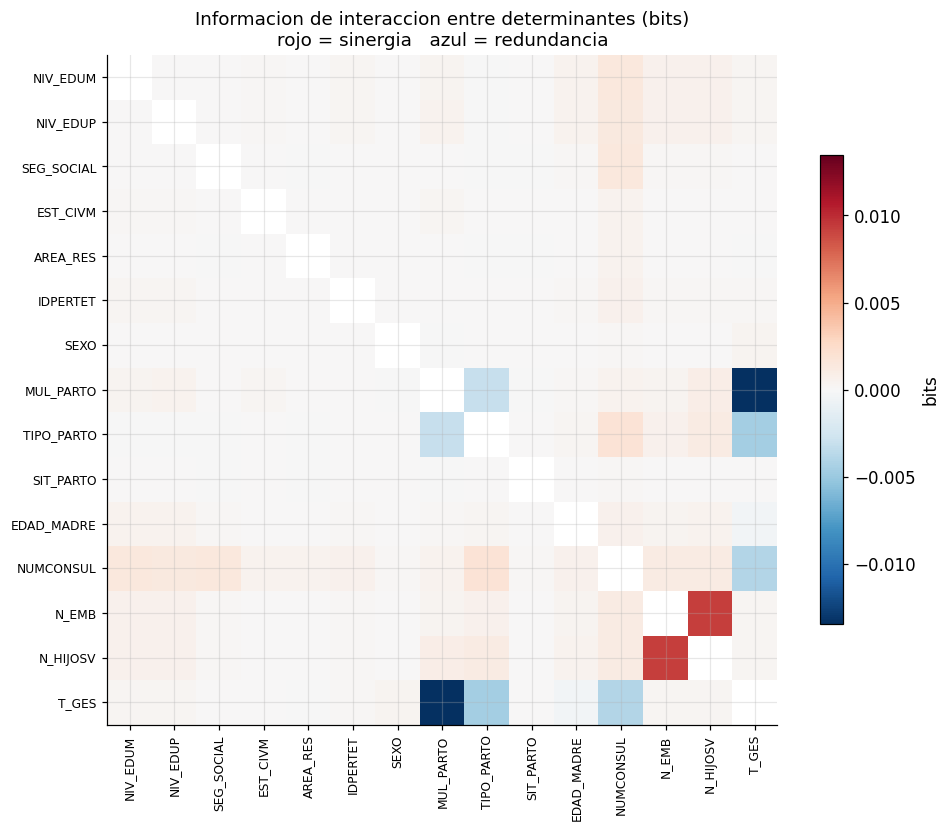

In [8]:
# ---------------------------------------------------------------------------
# Figura: mapa de calor de la informacion de interaccion
# ---------------------------------------------------------------------------

# Matriz cuadrada simetrica a partir del formato largo.
M = pd.DataFrame(np.nan, index=CANDIDATAS, columns=CANDIDATAS, dtype=float)
for _, r in inter.iterrows():
    M.loc[r["var_a"], r["var_b"]] = r["interaccion"]
    M.loc[r["var_b"], r["var_a"]] = r["interaccion"]

fig, ax = plt.subplots(figsize=(9, 7.5))
# Escala divergente centrada en cero: el signo es lo que importa, no la
# magnitud absoluta. Se simetriza el limite para que el blanco quede en 0.
lim = float(np.nanmax(np.abs(M.values)))
im_plot = ax.imshow(M.values, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.set_xticks(range(len(CANDIDATAS)))
ax.set_xticklabels(CANDIDATAS, rotation=90, fontsize=8)
ax.set_yticks(range(len(CANDIDATAS)))
ax.set_yticklabels(CANDIDATAS, fontsize=8)
ax.set_title("Informacion de interaccion entre determinantes (bits)\n"
             "rojo = sinergia   azul = redundancia")
fig.colorbar(im_plot, ax=ax, shrink=0.7, label="bits")
guardar_figura(fig, "fig_matriz_interaccion")
plt.show()

**Cómo se lee esta salida.**

- **Rojo = sinergia, azul = redundancia, blanco = independientes.** La diagonal está vacía a
  propósito: una variable consigo misma no tiene interacción.
- **Si aparece sinergia entre un determinante social y una variable obstétrica** —por
  ejemplo régimen de afiliación con número de consultas prenatales— eso es **acceso a
  servicios**, y es material sustantivo, no un detalle técnico. Es la interacción que la
  descomposición lineal repartiría mal entre efectos principales.
- **Si los determinantes sociales entre sí salen todos cerca de cero**, quiere decir que no
  hay redundancia entre educación, régimen y etnia: cada uno aporta información propia. Es
  un argumento a favor de **mantenerlos todos** en los modelos.
- **Redundancia fuerte con la edad gestacional** es esperable: es un mediador y absorbe parte
  de la información de las variables que están antes en la cadena causal.

**Qué va al manuscrito.** El mapa de calor como figura del Capítulo 5, y los tres o cuatro
pares de mayor sinergia comentados en el texto.

## 7. Criterio de retención y ámbito de aplicación

**Qué hacemos.** Aplicamos el criterio y dejamos escrito, en la propia salida, dónde se
aplica y dónde no.

**El criterio: dos vías.** Se retiene la variable si supera el percentil 95 de su nulo
**en marginal o en condicional**. Una sola vía dejaría fuera las variables que solo importan
por interacción, que es todo el argumento del bloque 3.

**El ámbito. Esta es la decisión metodológica central de la fase.**

- **En el componente predictivo, Fase 7, el cribado sí elimina variables.** El objetivo allí
  es el desempeño fuera de muestra; descartar predictores no informativos reduce la varianza
  sin comprometer ninguna interpretación causal.
- **En los modelos multinivel, Fases 4 y 5, no elimina ninguna.** Su especificación la fija
  el marco de determinantes sociales y la distinción entre confusor y mediador. Un confusor
  puede tener información mutua marginal baja y ser indispensable para estimar sin sesgo el
  efecto de otro determinante. Seleccionar covariables con criterios guiados por los datos
  sesga las estimaciones e invalida la cobertura de los intervalos de confianza, porque la
  incertidumbre del propio proceso de selección no entra en la varianza.

In [9]:
# ---------------------------------------------------------------------------
# Criterio de retencion: marginal O condicional
# ---------------------------------------------------------------------------

entraron = set(seleccion.loc[seleccion["supera_nulo"], "variable"])

cribado["supera_condicional"] = cribado["variable"].isin(entraron)
cribado["retenida"] = cribado["supera_marginal"] | cribado["supera_condicional"]
cribado["via"] = np.select(
    [cribado["supera_marginal"] & cribado["supera_condicional"],
     cribado["supera_marginal"],
     cribado["supera_condicional"]],
    ["ambas", "solo marginal", "solo condicional"],
    default="ninguna",
)

guardar_tabla(cribado, "cribado_mi", decimales=6)

print("RESULTADO DEL CRIBADO")
print(cribado[["variable", "bloque", "im_bits", "razon_nulo",
               "via", "retenida"]].to_string(index=False))

print(f"\nretenidas: {int(cribado['retenida'].sum())} de {len(cribado)}")
print(f"  por via: {cribado['via'].value_counts().to_dict()}")

descartadas = cribado.loc[~cribado["retenida"], "variable"].tolist()
print(f"\ndescartadas del COMPONENTE PREDICTIVO: {descartadas or 'ninguna'}")

print("\n" + "=" * 70)
print("AMBITO DE APLICACION")
print("=" * 70)
print("Fase 7, componente predictivo  -> el descarte SI se aplica")
print("Fases 4 y 5, modelos multinivel -> el descarte NO se aplica")
print()
print("Los modelos multinivel conservan su especificacion completa, determinada")
print("por el marco de determinantes sociales y por la distincion entre confusor")
print("y mediador. Un confusor puede tener IM marginal baja y ser indispensable")
print("para estimar sin sesgo el efecto de otro determinante.")

sociales_desc = [v for v in descartadas if v in SOCIALES]
if sociales_desc:
    print(f"\nATENCION: el cribado descarta determinantes SOCIALES: {sociales_desc}")
    print("Salen del componente predictivo, NO de los modelos multinivel.")
    print("Es la consecuencia esperable de que los mediadores obstetricos esten")
    print("mas cerca del desenlace en la cadena causal y absorban la informacion.")

tabla guardada: cribado_mi.csv y cribado_mi.tex
RESULTADO DEL CRIBADO
  variable     bloque  im_bits  razon_nulo           via  retenida
     T_GES obstetrica 0.110425      6585.2         ambas      True
 MUL_PARTO obstetrica 0.022246      1568.2         ambas      True
TIPO_PARTO obstetrica 0.007176       507.4 solo marginal      True
 NUMCONSUL obstetrica 0.006344        57.5         ambas      True
EDAD_MADRE obstetrica 0.000767        27.8 solo marginal      True
  EST_CIVM     social 0.000608        26.4 solo marginal      True
      SEXO obstetrica 0.000539        49.1 solo marginal      True
     N_EMB obstetrica 0.000510         8.5 solo marginal      True
  NIV_EDUP     social 0.000500         6.9 solo marginal      True
  NIV_EDUM     social 0.000434         6.7 solo marginal      True
  N_HIJOSV obstetrica 0.000346         7.2         ambas      True
SEG_SOCIAL     social 0.000303        16.7 solo marginal      True
  AREA_RES     social 0.000154        12.6 solo marginal   

**Cómo se lee esta salida.**

- **`via`** dice por qué entró cada variable. Las que entran **solo por la condicional** son
  la prueba de que el paso 5 hacía falta: un cribado marginal las habría perdido.
- **El aviso final sobre determinantes sociales** es el que hay que tener presente. Si
  aparece, no es un fallo: es la consecuencia de que los mediadores obstétricos estén más
  cerca del desenlace. Y es exactamente por lo que el descarte se limita al componente
  predictivo.

**Lo que hay que saber decir.**

> *El cribado ordena las variables por su asociación con el desenlace, y esa ordenación es
> un criterio razonable para reducir la dimensionalidad de un problema predictivo. No lo es
> para decidir qué covariables entran en un modelo con propósito inferencial. Por eso el
> descarte se aplica a la Fase 7 y no a los modelos multinivel.*

## 8. Cierre

In [10]:
# ---------------------------------------------------------------------------
# Cierre
# ---------------------------------------------------------------------------

from config import DIR_TABLAS, DIR_FIGURAS

print("TABLAS")
for f in sorted(DIR_TABLAS.glob("*.csv")):
    if f.stem in ("cribado_mi", "seleccion_adelante", "matriz_interaccion"):
        print(f"  {f}")

print("\nFIGURAS")
for f in sorted(DIR_FIGURAS.glob("fig_matriz_interaccion.*")):
    print(f"  {f}")

print("\nINTERMEDIOS")
print(f"  {DIR_INTERMEDIOS / 'particion.parquet'}")

print("\n" + "=" * 60)
versiones()

TABLAS
  C:\Users\ASUS\Desktop\TESIS\CODIGO_VSC\salidas\tablas\cribado_mi.csv
  C:\Users\ASUS\Desktop\TESIS\CODIGO_VSC\salidas\tablas\matriz_interaccion.csv
  C:\Users\ASUS\Desktop\TESIS\CODIGO_VSC\salidas\tablas\seleccion_adelante.csv

FIGURAS
  C:\Users\ASUS\Desktop\TESIS\CODIGO_VSC\salidas\figuras\fig_matriz_interaccion.pdf
  C:\Users\ASUS\Desktop\TESIS\CODIGO_VSC\salidas\figuras\fig_matriz_interaccion.png

INTERMEDIOS
  C:\Users\ASUS\Desktop\TESIS\CODIGO_VSC\intermedios\particion.parquet

python 3.9.23
pandas       2.3.3
numpy        1.26.4
scipy        1.13.1
sklearn      1.6.1
statsmodels  0.14.6
matplotlib   3.9.4
pyarrow      21.0.0


## Qué sigue

**`03_desigualdad.ipynb`**, Fase 3: índice de concentración y corrección de Erreygers.

Antes de pasar, comprueba:

- [ ] Las prevalencias de entrenamiento y prueba coinciden hasta la primera decimal
- [ ] En la simulación del bloque 3, `I(B;Y)` **no** supera su nulo y `I(B;Y|A)` es órdenes
      de magnitud mayor
- [ ] La selección hacia adelante se detuvo por agotamiento de estratos, no por error
- [ ] Sabes decir por qué el descarte se aplica solo a la Fase 7

**Tres cifras que hay que llevar a la reunión con el director:** $H(Y)$, cuántas variables se
retuvieron y por qué vía, y si algún determinante social quedó descartado del componente
predictivo.